<a href="https://colab.research.google.com/github/melike0019/GTZAN-Audio-Classification/blob/buse/baseline_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# SETUP HÜCRESİ — Her oturum başında bunu çalıştır
# Drive bağlantısı, kütüphaneler ve DataLoader burada hazırlanır
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader

# --- Processed veriyi Drive'dan yükle ---
PROC = "/content/drive/MyDrive/gtzan_project/Processed_Data"
X_train = np.load(f"{PROC}/X_train.npy")
y_train = np.load(f"{PROC}/y_train.npy")
X_val   = np.load(f"{PROC}/X_val.npy")
y_val   = np.load(f"{PROC}/y_val.npy")

# --- Melike'nin Dataset sınıfı ---
class GTZANDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        spec = self.X[idx].copy().astype(np.float32)
        label = int(self.y[idx])
        if self.augment:
            if np.random.rand() < 0.5:
                t_width = np.random.randint(5, 30)
                t_start = np.random.randint(0, max(1, spec.shape[1] - t_width))
                spec[:, t_start:t_start + t_width] = 0
            if np.random.rand() < 0.5:
                f_width = np.random.randint(3, 15)
                f_start = np.random.randint(0, max(1, spec.shape[0] - f_width))
                spec[f_start:f_start + f_width, :] = 0
        return torch.tensor(spec).unsqueeze(0), label

# --- DataLoader'lar ---
train_dl = DataLoader(GTZANDataset(X_train, y_train, augment=True),
                      batch_size=16, shuffle=True, num_workers=2,
                      pin_memory=True, drop_last=True)
val_dl   = DataLoader(GTZANDataset(X_val, y_val, augment=False),
                      batch_size=16, shuffle=False, num_workers=2,
                      pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Drive bağlandı")
print(f"✓ Veri yüklendi — Train: {X_train.shape}, Val: {X_val.shape}")
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Mounted at /content/drive
✓ Drive bağlandı
✓ Veri yüklendi — Train: (699, 128, 1292), Val: (150, 128, 1292)
✓ GPU: Tesla T4


In [2]:
# ============================================================
# BASELINE CNN MODELİ
# Amaç: Karmaşık bir model yazmadan önce basit bir CNN ile
#        ne kadar doğruluk alabileceğimizi ölçmek.
#        Bu model sonuçları, Derin CNN ile karşılaştırma
#        yaparken "taban çizgisi" (baseline) görevi görür.
# ============================================================

import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        # num_classes=10 çünkü GTZAN'da 10 müzik türü var
        super().__init__()

        self.features = nn.Sequential(

            # --- 1. KONVOLÜSYON BLOĞU ---
            # Giriş boyutu: (batch, 1, 128, 1292)
            # 1 → gri tonlamalı görüntü gibi tek kanallı spectrogram
            # 128 → mel band sayısı (frekans ekseni)
            # 1292 → zaman adımı sayısı
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            # 16 filtre öğreniyor: kenar, doku gibi basit örüntüler
            # padding=1 → boyutu korur, kenar pikseller kaybolmaz
            # Çıkış: (batch, 16, 128, 1292)

            nn.ReLU(),
            # Negatif değerleri sıfırlar, modele doğrusal olmayan
            # öğrenme kapasitesi kazandırır

            nn.MaxPool2d(2),
            # Her 2×2 bölgeden maksimum değeri alır
            # Boyutu yarıya indirir: (batch, 16, 64, 646)
            # Avantajı: küçük kaymalar/gürültüye karşı dayanıklılık

            # --- 2. KONVOLÜSYON BLOĞU ---
            # Daha derin örüntüler öğrenir (basit kenarlar → karmaşık şekiller)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            # 16 kanaldan 32 kanala çıkıyoruz → daha zengin özellik haritası
            # Çıkış: (batch, 32, 64, 646)

            nn.ReLU(),

            nn.MaxPool2d(2),
            # Tekrar yarıya indirir: (batch, 32, 32, 323)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),
            # 3 boyutlu feature map'i tek vektöre dönüştürür
            # 32 × 32 × 323 = 330,752 boyutlu vektör

            nn.Linear(32 * 32 * 323, 128),
            # Tam bağlantılı katman: 330,752 → 128
            # Öğrenilen özellikleri sınıflandırma için sıkıştırır

            nn.ReLU(),

            nn.Dropout(0.3),
            # Eğitim sırasında nöronların %30'unu rastgele kapatır
            # Amaç: modelin belirli nöronlara aşırı bağımlı olmasını engeller
            # Overfitting'i (ezberlemeyi) azaltır
            # NOT: Dropout sadece eğitimde aktif, model.eval() ile kapanır

            nn.Linear(128, num_classes),
            # Son katman: 128 → 10 (her tür için 1 çıkış)
            # Softmax KULLANMIYORUZ çünkü PyTorch'un CrossEntropyLoss
            # fonksiyonu Softmax'ı zaten içeriyor — çift uygularsak
            # matematiksel hata oluşur
        )

    def forward(self, x):
        # İleri geçiş: veri önce özellik çıkarımından,
        # sonra sınıflandırıcıdan geçer
        return self.classifier(self.features(x))


# Modeli GPU'ya taşı (T4 GPU varsa oraya, yoksa CPU'ya)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN().to(device)

print(f"✓ Cihaz: {device}")
print(f"✓ Toplam öğrenilebilir parametre: {sum(p.numel() for p in model.parameters()):,}")

✓ Cihaz: cuda
✓ Toplam öğrenilebilir parametre: 42,342,474


In [3]:
# ============================================================
# FORWARD PASS TESTİ
# Modele sahte veri göndererek boyutların doğru olduğunu
# kontrol ediyoruz. Gerçek eğitime geçmeden önce
# "model çalışıyor mu?" sorusunu cevaplıyoruz.
# ============================================================

# 2 örneklik sahte batch oluştur (gerçek veriye ihtiyaç yok)
dummy = torch.randn(2, 1, 128, 1292).to(device)
out = model(dummy)

print(f"Giriş boyutu : {dummy.shape}")  # (2, 1, 128, 1292)
print(f"Çıkış boyutu : {out.shape}")    # (2, 10) — 2 örnek, 10 tür
print("✓ Boyutlar doğru, model çalışıyor!")

Giriş boyutu : torch.Size([2, 1, 128, 1292])
Çıkış boyutu : torch.Size([2, 10])
✓ Boyutlar doğru, model çalışıyor!


In [6]:
# ============================================================
# OPTİMİZER VE LOSS FONKSİYONU
# Amaç: Modelin hangi yöntemle öğreneceğini ve hatasını
#        nasıl ölçeceğini belirliyoruz.
# ============================================================

# Adam optimizer: gradyan iniş yönteminin gelişmiş versiyonu
# lr=1e-3 → öğrenme hızı, çok büyük olursa model kararsız,
#            çok küçük olursa çok yavaş öğrenir
# val_ds ayrıca tanımlanması gerekiyor — len() için kullanıyoruz
val_ds = GTZANDataset(X_val, y_val, augment=False)
print(f"✓ val_ds: {len(val_ds)} örnek")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# CrossEntropyLoss: çok sınıflı sınıflandırma için standart kayıp fonksiyonu
# İçinde Softmax zaten var, ayrıca eklemeye gerek yok
loss_fn = nn.CrossEntropyLoss()

# Learning rate scheduler: her 10 epoch'ta lr'yi yarıya indirir
# Başta hızlı öğren, sonra ince ayar yap mantığı
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=10, gamma=0.5)

print("✓ Optimizer: Adam (lr=0.001)")
print("✓ Loss: CrossEntropyLoss")
print("✓ Scheduler: StepLR (her 10 epoch'ta lr×0.5)")

✓ val_ds: 150 örnek
✓ Optimizer: Adam (lr=0.001)
✓ Loss: CrossEntropyLoss
✓ Scheduler: StepLR (her 10 epoch'ta lr×0.5)


In [7]:
# ============================================================
# EĞİTİM DÖNGÜSÜ
# Her epoch'ta:
#   1) Tüm train batch'lerini modelden geçir
#   2) Loss hesapla, geri yayılım yap, ağırlıkları güncelle
#   3) Validation setinde doğruluğu ölç (model öğrendi mi?)
#   4) En iyi modeli kaydet
# ============================================================

EPOCHS = 30
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):

    # --- EĞİTİM AŞAMASI ---
    model.train()  # Dropout aktif olsun
    train_loss = 0.0

    for xb, yb in train_dl:
        xb = xb.to(device)  # veriyi GPU'ya taşı
        yb = torch.tensor(yb).to(device) if not isinstance(yb, torch.Tensor) else yb.to(device)

        optimizer.zero_grad()     # önceki gradyanları sıfırla
        preds = model(xb)         # ileri geçiş
        loss = loss_fn(preds, yb) # hatayı hesapla
        loss.backward()           # geri yayılım
        optimizer.step()          # ağırlıkları güncelle
        train_loss += loss.item()

    # --- VALİDASYON AŞAMASI ---
    model.eval()   # Dropout kapalı
    val_loss = 0.0
    correct = 0

    with torch.no_grad():  # gradyan hesaplamaya gerek yok
        for xb, yb in val_dl:
            xb = xb.to(device)
            yb = torch.tensor(yb).to(device) if not isinstance(yb, torch.Tensor) else yb.to(device)
            preds = model(xb)
            val_loss += loss_fn(preds, yb).item()
            correct += (preds.argmax(1) == yb).sum().item()

    # --- METRİKLERİ KAYDET ---
    avg_train_loss = train_loss / len(train_dl)
    avg_val_loss   = val_loss   / len(val_dl)
    val_acc        = correct    / len(val_ds)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    # --- EN İYİ MODELİ KAYDET ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/gtzan_project/Models/baseline_best.pth")
        print(f"Epoch {epoch+1:2d} | train_loss: {avg_train_loss:.4f} | "
              f"val_loss: {avg_val_loss:.4f} | val_acc: {val_acc:.3f} ✓ kaydedildi")
    else:
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2d} | train_loss: {avg_train_loss:.4f} | "
                  f"val_loss: {avg_val_loss:.4f} | val_acc: {val_acc:.3f}")

    scheduler.step()

print(f"\n✓ Eğitim tamamlandı! En iyi val accuracy: {best_val_acc:.3f}")

Epoch  1 | train_loss: 1.8876 | val_loss: 1.6464 | val_acc: 0.500 ✓ kaydedildi
Epoch  2 | train_loss: 1.2249 | val_loss: 1.3898 | val_acc: 0.567 ✓ kaydedildi
Epoch  3 | train_loss: 0.7331 | val_loss: 1.2308 | val_acc: 0.593 ✓ kaydedildi
Epoch  5 | train_loss: 0.2917 | val_loss: 1.2009 | val_acc: 0.567
Epoch  6 | train_loss: 0.2117 | val_loss: 1.1026 | val_acc: 0.627 ✓ kaydedildi
Epoch  7 | train_loss: 0.1803 | val_loss: 1.2393 | val_acc: 0.647 ✓ kaydedildi
Epoch 10 | train_loss: 0.1423 | val_loss: 1.1097 | val_acc: 0.620
Epoch 15 | train_loss: 0.0634 | val_loss: 1.4995 | val_acc: 0.600
Epoch 16 | train_loss: 0.0713 | val_loss: 1.5976 | val_acc: 0.653 ✓ kaydedildi
Epoch 20 | train_loss: 0.0932 | val_loss: 1.3375 | val_acc: 0.567
Epoch 25 | train_loss: 0.0377 | val_loss: 1.3448 | val_acc: 0.640
Epoch 26 | train_loss: 0.0330 | val_loss: 1.4294 | val_acc: 0.660 ✓ kaydedildi
Epoch 30 | train_loss: 0.0480 | val_loss: 1.4629 | val_acc: 0.620

✓ Eğitim tamamlandı! En iyi val accuracy: 0.660


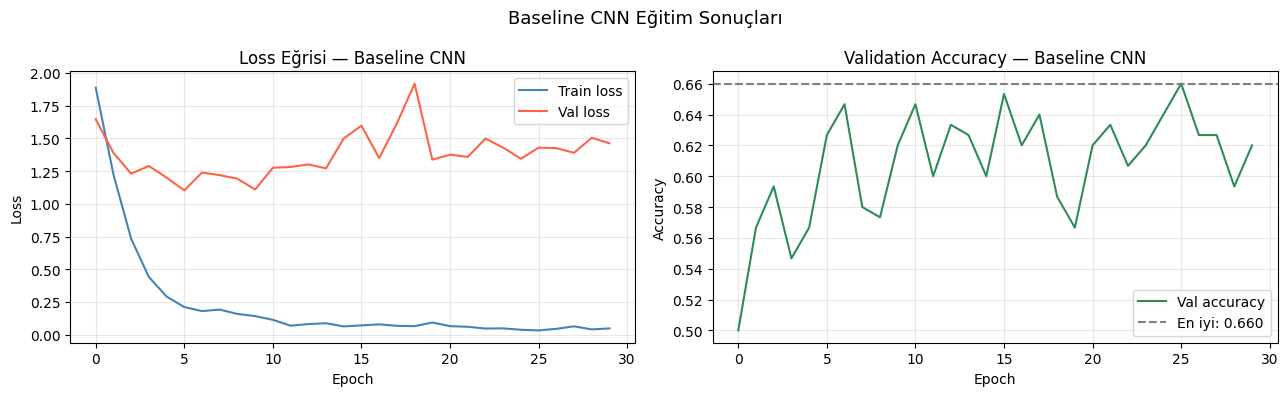

✓ Grafik Drive'a kaydedildi


In [8]:
# ============================================================
# EĞİTİM GRAFİKLERİ
# Loss ve accuracy eğrilerini çizerek modelin eğitim sürecini
# görselleştiriyoruz. Overfitting var mı? Model yakınsadı mı?
# ============================================================

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# --- Loss eğrisi ---
ax1.plot(history["train_loss"], label="Train loss", color="steelblue")
ax1.plot(history["val_loss"],   label="Val loss",   color="tomato")
ax1.set_title("Loss Eğrisi — Baseline CNN")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Accuracy eğrisi ---
ax2.plot(history["val_acc"], label="Val accuracy", color="seagreen")
ax2.axhline(y=best_val_acc, color="gray", linestyle="--",
            label=f"En iyi: {best_val_acc:.3f}")
ax2.set_title("Validation Accuracy — Baseline CNN")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("Baseline CNN Eğitim Sonuçları", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/gtzan_project/Models/baseline_egitim_grafigi.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Grafik Drive'a kaydedildi")

In [9]:
# ============================================================
# TEST SETİ DEĞERLENDİRMESİ
# Eğitim boyunca hiç görmediğimiz test seti üzerinde
# modelin gerçek performansını ölçüyoruz.
# En iyi kaydedilen modeli yüklüyoruz.
# ============================================================

from torch.utils.data import DataLoader
import numpy as np

# En iyi modeli yükle
X_test = np.load("/content/drive/MyDrive/gtzan_project/Processed_Data/X_test.npy")
y_test = np.load("/content/drive/MyDrive/gtzan_project/Processed_Data/y_test.npy")

test_ds = GTZANDataset(X_test, y_test, augment=False)
test_dl = DataLoader(test_ds, batch_size=16, shuffle=False,
                     num_workers=2, pin_memory=True)

# En iyi ağırlıkları yükle
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/gtzan_project/Models/baseline_best.pth"))
model.eval()

correct = 0
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        yb = yb.to(device) if isinstance(yb, torch.Tensor) else torch.tensor(yb).to(device)
        preds = model(xb)
        correct += (preds.argmax(1) == yb).sum().item()

test_acc = correct / len(test_ds)
print(f"✓ Baseline CNN Test Accuracy: {test_acc:.3f} ({test_acc*100:.1f}%)")
print(f"✓ Val Accuracy (en iyi):      {best_val_acc:.3f} ({best_val_acc*100:.1f}%)")

✓ Baseline CNN Test Accuracy: 0.660 (66.0%)
✓ Val Accuracy (en iyi):      0.660 (66.0%)
